In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
trash_df = pd.read_csv('../data/trash_hauler_report.csv')
trash_df.head()

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
0,25270,11/1/2017,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207.0,RED RIVER,3205,2.0,1727970.412,686779.4781
1,25274,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218.0,RED RIVER,4202,1.0,1721259.366,685444.7996
2,25276,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209.0,RED RIVER,4205,20.0,1707026.753,659887.4716
3,25307,11/1/2017,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1735691.771,685027.2459
4,25312,11/1/2017,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley dr,37209.0,RED RIVER,4203,20.0,1710185.772,664205.1011


In [3]:
trash_df.shape

(20226, 11)

In [4]:
trash_df['Request '].value_counts()

Request 
Trash - Curbside/Alley Missed Pickup    15028
Trash - Backdoor                         2629
Trash Collection Complaint               2312
Damage to Property                        257
Name: count, dtype: int64

In [5]:
trash_df = trash_df.rename(columns = {'Request ': 'Request'})
trash_df.columns

Index(['Request Number', 'Date Opened', 'Request', 'Description',
       'Incident Address', 'Zip Code', 'Trash Hauler', 'Trash Route',
       'Council District', 'State Plan X', 'State Plan Y'],
      dtype='object')

In [6]:
trash_df['Trash Hauler'] = trash_df['Trash Hauler'].replace('Metro', 'METRO')

In [7]:
trash_df['Request'].value_counts()

Request
Trash - Curbside/Alley Missed Pickup    15028
Trash - Backdoor                         2629
Trash Collection Complaint               2312
Damage to Property                        257
Name: count, dtype: int64

In [8]:
request_count = trash_df['Request'].value_counts()
request_count = request_count.reset_index()
request_count

,Request,count
0,Trash - Curbside/Alley Missed Pickup,15028
1,Trash - Backdoor,2629
2,Trash Collection Complaint,2312
3,Damage to Property,257


In [9]:
trash_df['Zip Code'].dtype

dtype('float64')

In [10]:
trash_df['Zip Code'].astype(float).astype(str).str.replace('.0','')

0        37207
1        37218
2        37209
3        37207
4        37209
         ...  
20221    37013
20222    37206
20223    37214
20224    37013
20225    37217
Name: Zip Code, Length: 20226, dtype: object

In [11]:
trash_df['Zip Code'] = trash_df['Zip Code'].astype(float).astype(str).str.replace('.0','')
trash_df.head()

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
0,25270,11/1/2017,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207,RED RIVER,3205,2.0,1727970.412,686779.4781
1,25274,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218,RED RIVER,4202,1.0,1721259.366,685444.7996
2,25276,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209,RED RIVER,4205,20.0,1707026.753,659887.4716
3,25307,11/1/2017,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207,WASTE IND,2206,2.0,1735691.771,685027.2459
4,25312,11/1/2017,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley dr,37209,RED RIVER,4203,20.0,1710185.772,664205.1011


In [12]:
trash_df['Zip Code'].value_counts().head()

Zip Code
37013    2278
37211    2248
37205    1491
37209    1411
37215    1404
Name: count, dtype: int64

In [13]:
zip_count = trash_df['Zip Code'].value_counts()
zip_count = zip_count.reset_index()
zip_count.head()

,Zip Code,count
0,37013,2278
1,37211,2248
2,37205,1491
3,37209,1411
4,37215,1404


In [14]:
trash_df['Incident Address'] = trash_df['Incident Address'].str.title()
trash_df.head()

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
0,25270,11/1/2017,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207,RED RIVER,3205,2.0,1727970.412,686779.4781
1,25274,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218,RED RIVER,4202,1.0,1721259.366,685444.7996
2,25276,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209,RED RIVER,4205,20.0,1707026.753,659887.4716
3,25307,11/1/2017,Trash - Curbside/Alley Missed Pickup,missed,2603 Old Matthews Rd,37207,WASTE IND,2206,2.0,1735691.771,685027.2459
4,25312,11/1/2017,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 Croley Dr,37209,RED RIVER,4203,20.0,1710185.772,664205.1011


In [15]:
trash_df['Address'] = trash_df['Incident Address'].str.split(',', expand = True)[0]

In [16]:
trash_df['City'] = trash_df['Incident Address'].str.split(',', expand = True)[1]
trash_df.head()

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y,Address,City
0,25270,11/1/2017,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207,RED RIVER,3205,2.0,1727970.412,686779.4781,3817 Crouch Dr,None
1,25274,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218,RED RIVER,4202,1.0,1721259.366,685444.7996,4028 Clarksville Pike,None
2,25276,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209,RED RIVER,4205,20.0,1707026.753,659887.4716,6528 Thunderbird Dr,None
3,25307,11/1/2017,Trash - Curbside/Alley Missed Pickup,missed,2603 Old Matthews Rd,37207,WASTE IND,2206,2.0,1735691.771,685027.2459,2603 Old Matthews Rd,None
4,25312,11/1/2017,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 Croley Dr,37209,RED RIVER,4203,20.0,1710185.772,664205.1011,604 Croley Dr,None


In [17]:
address_count = trash_df['Incident Address'].value_counts()
address_count = address_count.reset_index()
address_count.head()

,Incident Address,count
0,3710 N Natchez Ct,21
1,5135 Hickory Hollow Pkwy,21
2,"6007 Obrien Ave, Nashville, Tn 37209, United S...",19
3,"12546 Old Hickory Blvd, Nashville, Tn 37013, U...",19
4,"802 Crescent Rd, Nashville, Tn 37205, United S...",18


In [18]:
Address_count = trash_df['Address'].value_counts()
Address_count = Address_count.reset_index()
Address_count.head()

,Address,count
0,110 George L Davis Blvd,29
1,5135 Hickory Hollow Pkwy,23
2,3710 N Natchez Ct,22
3,12546 Old Hickory Blvd,21
4,6007 Obrien Ave,20


In [19]:
# this didnt work
# missed_text = ['missed', 'miss', 'skip', 'skipped', 'not picked', 'failed', 'fail', 'forgot']

In [20]:
# old method for filtering misses
# trash_df['Missed Trash'] = trash_df['Description'].str.contains('missed|miss|skip|skipped|not picked|failed|fail|forgot|never|did not', case=False, na=False)
# trash_df.head()

In [21]:
trash_df['Missed Trash'] = (trash_df['Description'].str.contains('missed|miss|skip|skipped|not picked|failed|fail|forgot|never|did not', case=False, na=False)
    | (trash_df['Request'] == 'Trash - Curbside/Alley Missed Pickup'))
trash_df.head()

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y,Address,City,Missed Trash
0,25270,11/1/2017,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207,RED RIVER,3205,2.0,1727970.412,686779.4781,3817 Crouch Dr,None,False
1,25274,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218,RED RIVER,4202,1.0,1721259.366,685444.7996,4028 Clarksville Pike,None,True
2,25276,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209,RED RIVER,4205,20.0,1707026.753,659887.4716,6528 Thunderbird Dr,None,True
3,25307,11/1/2017,Trash - Curbside/Alley Missed Pickup,missed,2603 Old Matthews Rd,37207,WASTE IND,2206,2.0,1735691.771,685027.2459,2603 Old Matthews Rd,None,True
4,25312,11/1/2017,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 Croley Dr,37209,RED RIVER,4203,20.0,1710185.772,664205.1011,604 Croley Dr,None,True


In [22]:
# checking for miss matched 'Missed' columns
# (trash_df['Missed Trash'] != trash_df['Missed2']).sum()

In [23]:
trash_df['Missed Trash'].value_counts()

Missed Trash
True     18030
False     2196
Name: count, dtype: int64

In [24]:
hauler_count = trash_df['Missed Trash'].groupby(trash_df['Trash Hauler']).value_counts()
hauler_count = hauler_count.reset_index()
hauler_count.head()

,Trash Hauler,Missed Trash,count
0,METRO,True,3085
1,METRO,False,495
2,RED RIVER,True,13025
3,RED RIVER,False,1370
4,WASTE IND,True,1152


In [53]:
# plt.figure(figsize=(10, 6))
# count_missed_bar = sns.barplot(data = hauler_count, x = 'count', y = 'Trash Hauler', errorbar = None);
# count_missed_bar.set_title('Count of Missed Trash by Trash Hauler')
# count_missed_bar.set_xlabel('Count Missed')
# count_missed_bar.set_ylabel('Trash Hauler')
# count_missed_bar.grid(axis='x')
##count_missed_bar.set_xticks(range(0, 1000000, 100000))
# plt.savefig('amount_owed_by_hauler.png', dpi=300, bbox_inches='tight')
# plt.show()
# sns.barplot

In [26]:
trash_df['address_zip'] = trash_df['Address'] + ' ' + trash_df['Zip Code']
trash_df.head()

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y,Address,City,Missed Trash,address_zip
0,25270,11/1/2017,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207,RED RIVER,3205,2.0,1727970.412,686779.4781,3817 Crouch Dr,None,False,3817 Crouch Dr 37207
1,25274,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218,RED RIVER,4202,1.0,1721259.366,685444.7996,4028 Clarksville Pike,None,True,4028 Clarksville Pike 37218
2,25276,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209,RED RIVER,4205,20.0,1707026.753,659887.4716,6528 Thunderbird Dr,None,True,6528 Thunderbird Dr 37209
3,25307,11/1/2017,Trash - Curbside/Alley Missed Pickup,missed,2603 Old Matthews Rd,37207,WASTE IND,2206,2.0,1735691.771,685027.2459,2603 Old Matthews Rd,None,True,2603 Old Matthews Rd 37207
4,25312,11/1/2017,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 Croley Dr,37209,RED RIVER,4203,20.0,1710185.772,664205.1011,604 Croley Dr,None,True,604 Croley Dr 37209


In [27]:
# do not use, count based on original Missed Trash filter approach
# trash_df.loc[trash_df['Missed Trash'] == True].groupby(trash_df['Trash Hauler'])['Address3'].count()

In [28]:
trash_df.loc[trash_df['Missed Trash'] == True].groupby(trash_df['Trash Hauler'])['address_zip'].count()
# trash_df.loc[trash_df['Missed Trash'] == True].groupby('Trash Hauler')['Address3'].count() # samething

Trash Hauler
METRO         3084
RED RIVER    13024
WASTE IND     1152
Name: address_zip, dtype: int64

In [29]:
route_count = (trash_df.loc[trash_df['Missed Trash'] == True].groupby('Trash Route')['address_zip'].count().reset_index(name='route_count'))
route_count = route_count.sort_values('route_count', ascending=False)
route_count.head()

,Trash Route,route_count
133,4504,334
74,3302,295
124,4404,261
150,9303,251
9,1303,251


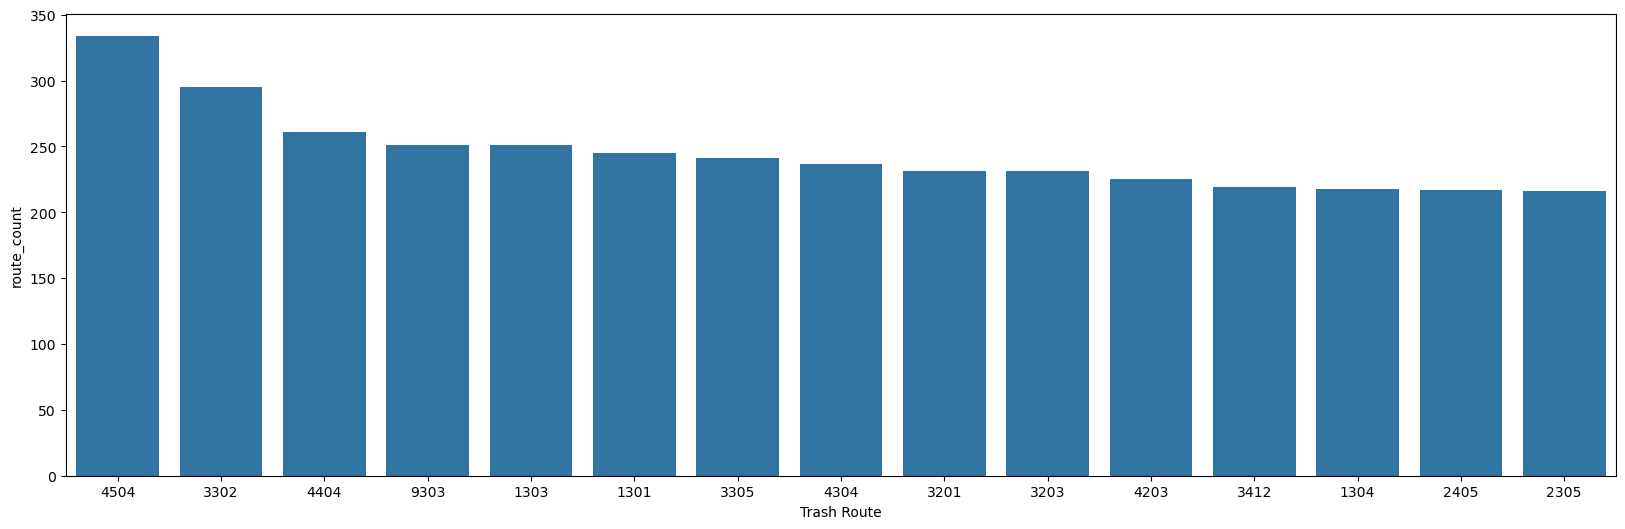

In [30]:
top_15_routes = route_count.nlargest(15, 'route_count')
plt.figure(figsize=(20, 6))
sns.barplot(data=top_15_routes, x='Trash Route', y='route_count', errorbar=None);


In [31]:
address_zip_count = trash_df['address_zip'].value_counts()
address_zip_count = address_zip_count.reset_index()
address_zip_count.head()

,address_zip,count
0,110 George L Davis Blvd 37203,28
1,5135 Hickory Hollow Pkwy 37013,23
2,3710 N Natchez Ct 37211,22
3,12546 Old Hickory Blvd 37013,21
4,6007 Obrien Ave 37209,20


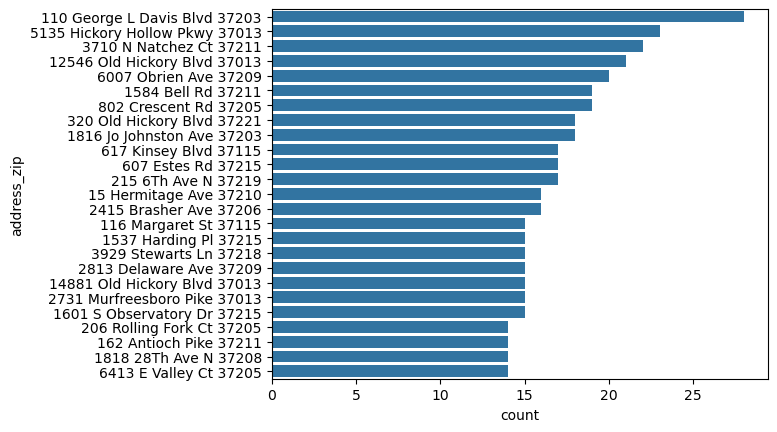

In [32]:
top_25_addresses = address_zip_count.nlargest(25, 'count')

sns.barplot(data=top_25_addresses, x='count', y='address_zip', errorbar=None);

In [33]:
# plt.hist(address_zip_count['count'], bins=15);

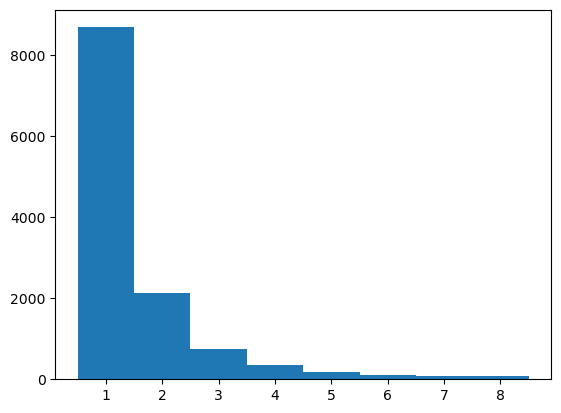

In [34]:
# change to manual range for better clarity
plt.hist(address_zip_count['count'],bins=range(1, 10, 1), align = 'left');

In [35]:
address_zip_count = (trash_df[trash_df['Missed Trash']].groupby(['Trash Hauler', 'address_zip']).size().reset_index(name='count'))
address_zip_count['missed_pickups'] = address_zip_count['count'] - 1
address_zip_count['amount_owed'] = address_zip_count['missed_pickups'] * 200
address_zip_count

,Trash Hauler,address_zip,count,missed_pickups,amount_owed
0,METRO,1 Belle Forrest Ave C 37206,1,0,0
1,METRO,10 Belle Forrest Ave 37206,1,0,0
2,METRO,100 Marshall Ct 37212,2,1,200
3,METRO,1000 Gilmore Ave 37204,1,0,0
4,METRO,1000 N 7Th St 37207,1,0,0
...,...,...,...,...,...
11081,WASTE IND,944 4Th Ave S 37210,2,1,200
11082,WASTE IND,945 31St Ave N 37209,1,0,0
11083,WASTE IND,945 4Th Ave S 37210,2,1,200
11084,WASTE IND,951 Sharpe Ave 37206,1,0,0


In [36]:
owed_by_hauler = address_zip_count['amount_owed'].groupby(address_zip_count['Trash Hauler']).sum()
owed_by_hauler = owed_by_hauler.reset_index()
owed_by_hauler.head()

,Trash Hauler,amount_owed
0,METRO,222000
1,RED RIVER,934800
2,WASTE IND,78000


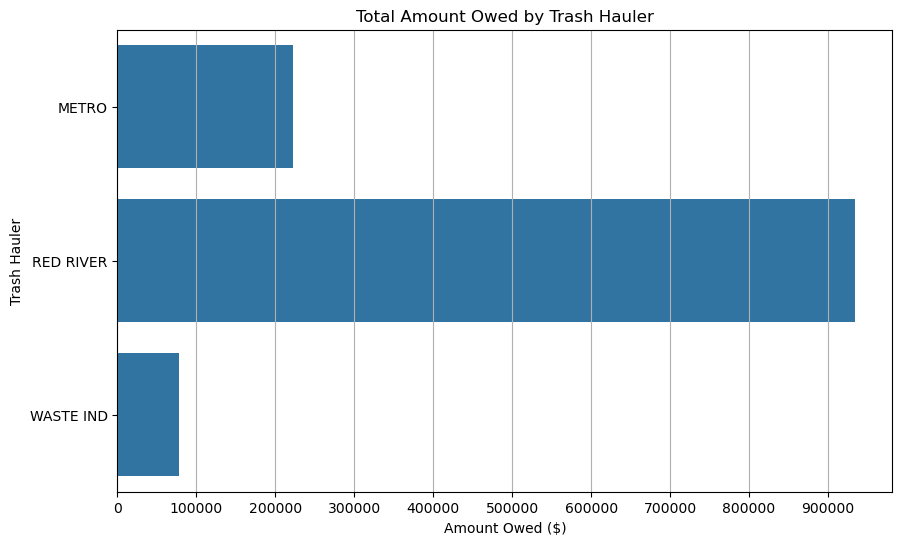

In [37]:
plt.figure(figsize=(10, 6))

amount_owed_bar = sns.barplot(data = owed_by_hauler, x = 'amount_owed', y = 'Trash Hauler', errorbar = None);
amount_owed_bar.set_title('Total Amount Owed by Trash Hauler')
amount_owed_bar.set_xlabel('Amount Owed ($)')
amount_owed_bar.set_ylabel('Trash Hauler')
amount_owed_bar.grid(axis='x')
amount_owed_bar.set_xticks(range(0, 1000000, 100000))
plt.savefig('owed_by_hauler.png', dpi=300, bbox_inches='tight')
plt.show()

In [38]:
missed_count_hauler = (address_zip_count.groupby('Trash Hauler')['missed_pickups'].sum().reset_index(name='total_missed_pickups'))
missed_count_hauler

,Trash Hauler,total_missed_pickups
0,METRO,1110
1,RED RIVER,4674
2,WASTE IND,390


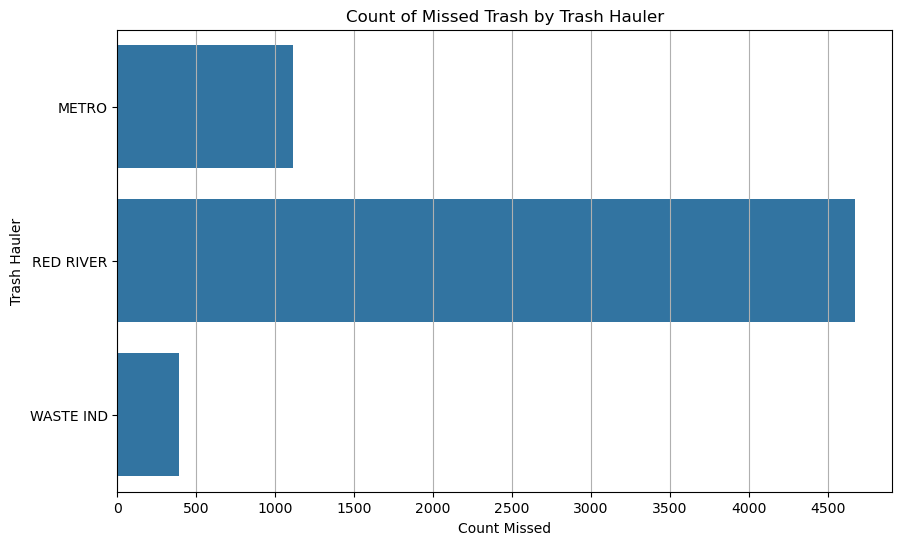

In [63]:
plt.figure(figsize=(10, 6))
missed_count_hauler_bar = sns.barplot(data = missed_count_hauler, x = 'total_missed_pickups', y = 'Trash Hauler', errorbar = None);
missed_count_hauler_bar.set_title('Count of Missed Trash by Trash Hauler')
missed_count_hauler_bar.set_xlabel('Count Missed')
missed_count_hauler_bar.set_ylabel('Trash Hauler')
missed_count_hauler_bar.grid(axis='x')
missed_count_hauler_bar.set_xticks(range(0, 5000, 500))
plt.savefig('missed_count_hauler_bar.png', dpi=300, bbox_inches='tight')
plt.show()

In [39]:
trash_df.loc[trash_df['Missed Trash'] == True, 'address_zip'].groupby(trash_df['Trash Hauler']).count()

Trash Hauler
METRO         3084
RED RIVER    13024
WASTE IND     1152
Name: address_zip, dtype: int64

In [40]:
# can be deleted, not used
# not_missed_desc = trash_df.loc[trash_df['Missed Trash'] == False]['Description']
# not_missed_desc = not_missed_desc.reset_index()
# not_missed_desc

In [46]:
trash_df['Street Name'] = trash_df['Address'].str.replace('^\d+\s*', '', regex=True)
trash_df['street_zip'] = trash_df['Street Name'] + ' ' + trash_df['Zip Code'].astype(str)
missed_street_zip_count = (trash_df['street_zip'].value_counts().reset_index(name='count').rename(columns={'index': 'street_zip'}))
missed_street_zip_count

,street_zip,count
0,Buena Vista Pike 37218,99
1,Granny White Pike 37204,78
2,Old Hickory Blvd 37013,74
3,Antioch Pike 37211,69
4,Golf Club Ln 37215,68
...,...,...
3801,Goldilocks St 37115,1
3802,Huffine St 37216,1
3803,A Elliott Ave 37203,1
3804,Mccarthy Park Ln 37207,1


In [47]:
missed_street_count = (trash_df['Street Name'].value_counts().reset_index(name='count').rename(columns={'index': 'Street Name'}))
missed_street_count

,Street Name,count
0,Old Hickory Blvd,156
1,Buena Vista Pike,100
2,Harding Pl,98
3,Granny White Pike,89
4,Bell Rd,73
...,...,...
3598,Scovel St 2,1
3599,Gatewood Ave D,1
3600,Brookwood Pl,1
3601,Knight Cir,1


In [49]:
trash_df.head()

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,...,Missed Trash,address_zip,Street Name,street_zip,Year,Month,Day,Day of Week Name,Quarter,Hour
0,25270,2017-11-01,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207,RED RIVER,3205,2.0,1727970.412,...,False,3817 Crouch Dr 37207,Crouch Dr,Crouch Dr 37207,2017,11,1,Wednesday,4,0
1,25274,2017-11-01,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218,RED RIVER,4202,1.0,1721259.366,...,True,4028 Clarksville Pike 37218,Clarksville Pike,Clarksville Pike 37218,2017,11,1,Wednesday,4,0
2,25276,2017-11-01,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209,RED RIVER,4205,20.0,1707026.753,...,True,6528 Thunderbird Dr 37209,Thunderbird Dr,Thunderbird Dr 37209,2017,11,1,Wednesday,4,0
3,25307,2017-11-01,Trash - Curbside/Alley Missed Pickup,missed,2603 Old Matthews Rd,37207,WASTE IND,2206,2.0,1735691.771,...,True,2603 Old Matthews Rd 37207,Old Matthews Rd,Old Matthews Rd 37207,2017,11,1,Wednesday,4,0
4,25312,2017-11-01,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 Croley Dr,37209,RED RIVER,4203,20.0,1710185.772,...,True,604 Croley Dr 37209,Croley Dr,Croley Dr 37209,2017,11,1,Wednesday,4,0


In [50]:
trash_df['Date Opened'] = pd.to_datetime(trash_df['Date Opened'])

In [51]:
trash_df['Year'] = trash_df['Date Opened'].dt.year
trash_df['Month'] = trash_df['Date Opened'].dt.month
trash_df['Day'] = trash_df['Date Opened'].dt.day
trash_df['Day of Week Name'] = trash_df['Date Opened'].dt.day_name()
trash_df['Quarter'] = trash_df['Date Opened'].dt.quarter
trash_df['Hour'] = trash_df['Date Opened'].dt.hour
trash_df.head()

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,...,Missed Trash,address_zip,Street Name,street_zip,Year,Month,Day,Day of Week Name,Quarter,Hour
0,25270,2017-11-01,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207,RED RIVER,3205,2.0,1727970.412,...,False,3817 Crouch Dr 37207,Crouch Dr,Crouch Dr 37207,2017,11,1,Wednesday,4,0
1,25274,2017-11-01,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218,RED RIVER,4202,1.0,1721259.366,...,True,4028 Clarksville Pike 37218,Clarksville Pike,Clarksville Pike 37218,2017,11,1,Wednesday,4,0
2,25276,2017-11-01,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209,RED RIVER,4205,20.0,1707026.753,...,True,6528 Thunderbird Dr 37209,Thunderbird Dr,Thunderbird Dr 37209,2017,11,1,Wednesday,4,0
3,25307,2017-11-01,Trash - Curbside/Alley Missed Pickup,missed,2603 Old Matthews Rd,37207,WASTE IND,2206,2.0,1735691.771,...,True,2603 Old Matthews Rd 37207,Old Matthews Rd,Old Matthews Rd 37207,2017,11,1,Wednesday,4,0
4,25312,2017-11-01,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 Croley Dr,37209,RED RIVER,4203,20.0,1710185.772,...,True,604 Croley Dr 37209,Croley Dr,Croley Dr 37209,2017,11,1,Wednesday,4,0


In [87]:
hauler_mo_df = trash_df.groupby(['Trash Hauler', 'Month'])['Missed Trash'].sum().reset_index()
hauler_mo_df.head()

,Trash Hauler,Month,Missed Trash
0,METRO,1,214
1,METRO,2,197
2,METRO,3,265
3,METRO,4,244
4,METRO,5,286


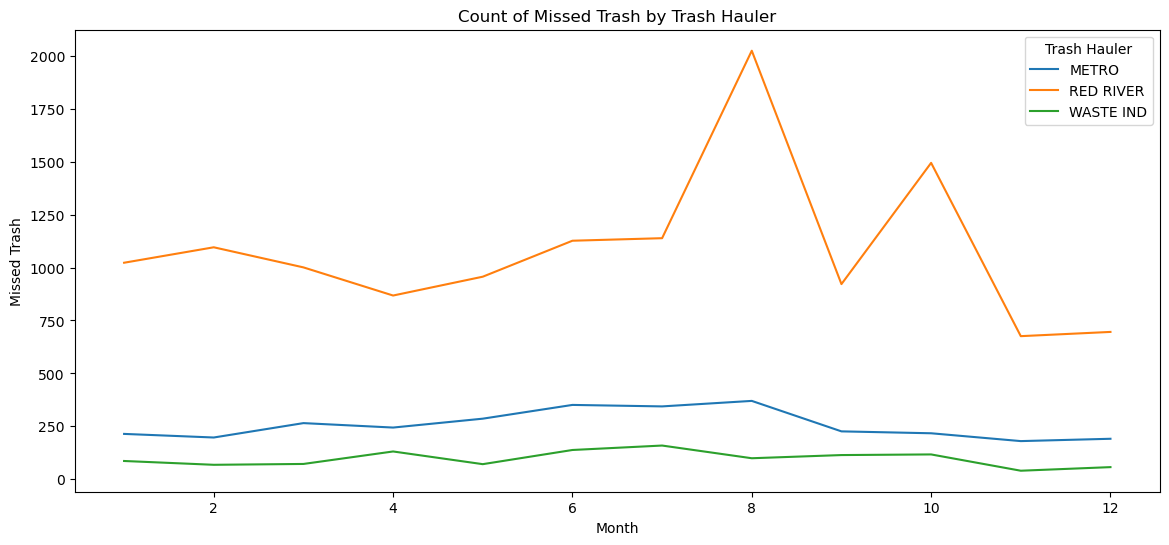

In [103]:
plt.figure(figsize=(14, 6))
hauler_mo_df_line = sns.lineplot(data = hauler_mo_df, x = 'Month', y = 'Missed Trash', hue = 'Trash Hauler');
hauler_mo_df_line.set_title('Count of Missed Trash by Trash Hauler')
hauler_mo_df_line.set_xlabel('Month')
hauler_mo_df_line.set_ylabel('Missed Trash')
hauler_mo_df_bar.grid(axis='y')
#hauler_mo_df_bar.set_xticks(range(0, 5000, 500))
plt.savefig('hauler_mo_df_line.png', dpi=300, bbox_inches='tight')
#plt.show()

In [95]:
hauler_mo_df['pct_of_hauler_complaints'] = (hauler_mo_df['Missed Trash'] / hauler_mo_df.groupby('Trash Hauler')['Missed Trash'].transform('sum'))
hauler_mo_df['pct_of_hauler_complaints'] = hauler_mo_df['pct_of_hauler_complaints'] * 100
hauler_mo_df.head()

,Trash Hauler,Month,Missed Trash,pct_of_hauler_total,pct_of_hauler_complaints
0,METRO,1,214,0.069368,6.936791
1,METRO,2,197,0.063857,6.385737
2,METRO,3,265,0.085900,8.589951
3,METRO,4,244,0.079092,7.909238
4,METRO,5,286,0.092707,9.270665


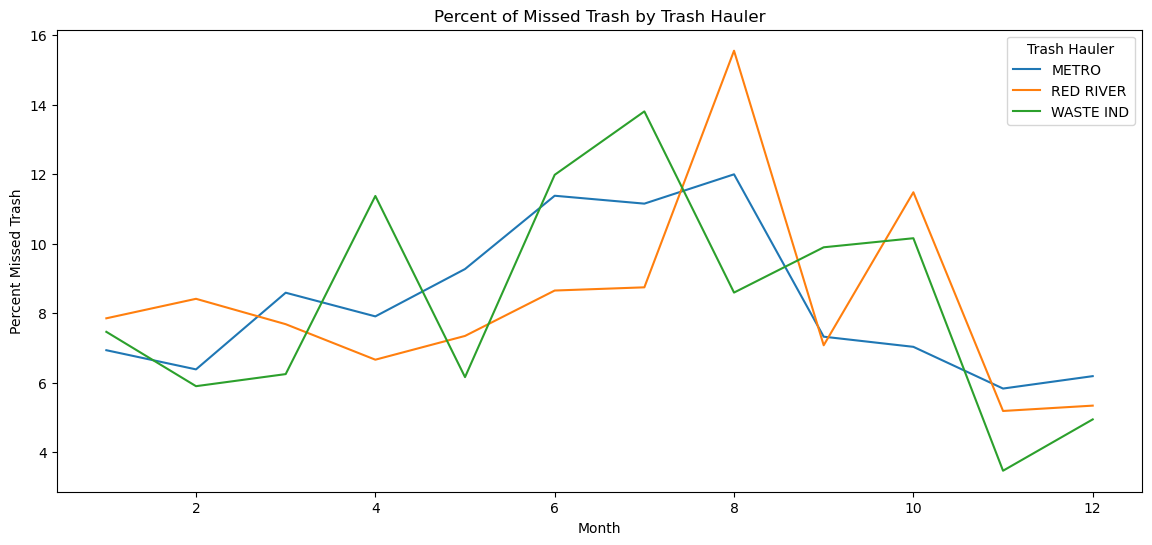

In [105]:
plt.figure(figsize=(14, 6))
hauler_mo_df_pct_line = sns.lineplot(data=hauler_mo_df, x='Month', y='pct_of_hauler_complaints', hue='Trash Hauler')
hauler_mo_df_pct_line.set_title('Percent of Missed Trash by Trash Hauler')
hauler_mo_df_pct_line.set_xlabel('Month')
hauler_mo_df_pct_line.set_ylabel('Percent Missed Trash')
plt.savefig('hauler_mo_df_pct_line.png', dpi=300, bbox_inches='tight')

In [113]:
# address_zip_count['amount_owed']
hauler_day_df = trash_df.groupby(['Trash Hauler', 'Day of Week Name'])['Missed Trash'].sum().reset_index()
hauler_day_df.sort_values(['Trash Hauler', 'Missed Trash'], ascending = False).head()

,Trash Hauler,Day of Week Name,Missed Trash
18,WASTE IND,Thursday,287
20,WASTE IND,Wednesday,286
14,WASTE IND,Friday,231
19,WASTE IND,Tuesday,161
15,WASTE IND,Monday,143


In [117]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

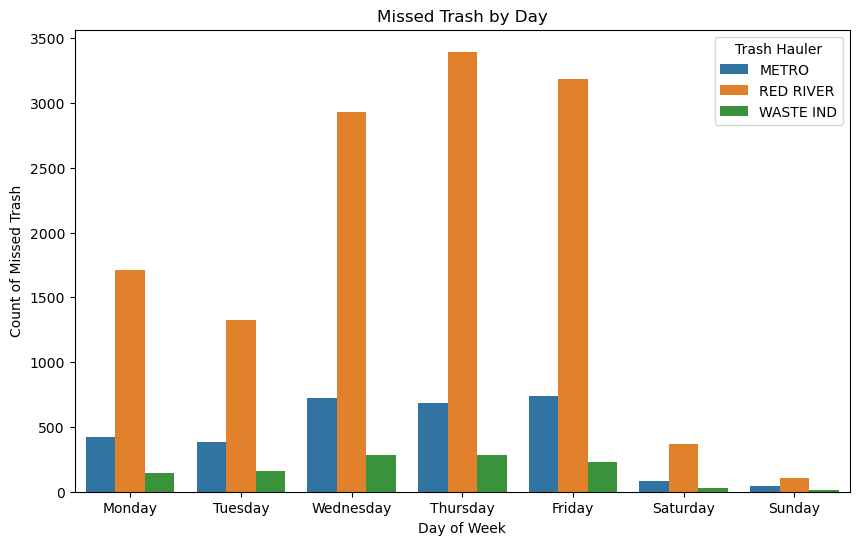

In [119]:
plt.figure(figsize=(10, 6))
hauler_day_bar = sns.barplot(data = hauler_day_df, x = 'Day of Week Name', y = 'Missed Trash', errorbar = None, hue='Trash Hauler', order = day_order);
hauler_day_bar.set_title('Missed Trash by Day')
hauler_day_bar.set_xlabel('Day of Week')
hauler_day_bar.set_ylabel('Count of Missed Trash')
#hauler_day_bar.grid(axis='x')
#hauler_day_bar.set_xticks(range(0, 5000, 500))
plt.savefig('hauler_day_bar.png', dpi=300, bbox_inches='tight')
plt.show()

In [121]:
hauler_day_df['pct_of_hauler_complaints'] = (hauler_day_df['Missed Trash'] / hauler_day_df.groupby('Trash Hauler')['Missed Trash'].transform('sum'))
hauler_day_df['pct_of_hauler_complaints'] = hauler_day_df['pct_of_hauler_complaints'] * 100
hauler_day_df.head()

,Trash Hauler,Day of Week Name,Missed Trash,pct_of_hauler_complaints
0,METRO,Friday,741,24.019449
1,METRO,Monday,420,13.614263
2,METRO,Saturday,84,2.722853
3,METRO,Sunday,42,1.361426
4,METRO,Thursday,684,22.171799


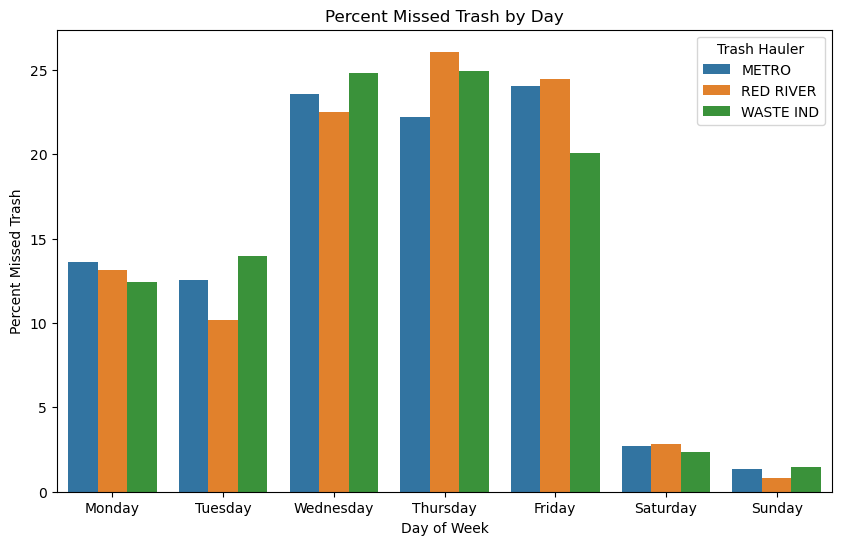

In [122]:
plt.figure(figsize=(10, 6))
hauler_day_bar = sns.barplot(data = hauler_day_df, x = 'Day of Week Name', y = 'pct_of_hauler_complaints', errorbar = None, hue='Trash Hauler', order = day_order);
hauler_day_bar.set_title('Percent Missed Trash by Day')
hauler_day_bar.set_xlabel('Day of Week')
hauler_day_bar.set_ylabel('Percent Missed Trash')
#hauler_day_bar.grid(axis='x')
#hauler_day_bar.set_xticks(range(0, 5000, 500))
plt.savefig('hauler_day_bar.png', dpi=300, bbox_inches='tight')
plt.show()